In [1]:
# Install external dependencies when running this notebook on a new machine.
# Run this cell once if imports fail, then restart the kernel.
%pip install numpy scipy matplotlib ipython


Note: you may need to restart the kernel to use updated packages.


# Passive Brachiation on an Inclined Slope

This notebook simulates a two-link passive brachiation model on a continuous inclined
plane instead of a discrete ladder.

**Key differences from the original rung‑based model:**

- The surface is an infinite slope defined by angle `gamma` (z = −y·tan γ).
- Contact is detected by zero‑crossing of signed distance to the slope.
- After impact, velocity resets to zero (double‑support assumption).
- A three‑way switch policy decides SWITCH / NO_SWITCH / DWELL.
- Poincaré analysis uses the slope surface as the section (free end z relative to surface).

**Simulation phases:** SWINGING → IMPACT → DWELL → RELEASE → back to SWINGING.

## 1. Imports

In [2]:
import sys
from pathlib import Path

# Avoid writing __pycache__ files in the OneDrive project folder.
sys.dont_write_bytecode = True

# Make the project root importable even if the notebook is launched elsewhere.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "passive_brachiation").exists():
    PROJECT_ROOT = Path(r"c:\Users\82646\OneDrive\桌面\Chalmers work\p4\TRA455 Artistic Intelligence in Robotics\Project")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

from passive_brachiation import (
    BrachiationParameters,
    BrachiationState,
    TwoLinkBrachiationModel,
    Slope,
    SwitchDecision,
    SimPhase,
    simulate,
    forward_kinematics,
    CollisionMode,
    make_passive_brachiation_stride_map,
)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["animation.embed_limit"] = 30

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\82646\OneDrive\桌面\Chalmers work\p4\TRA455 Artistic Intelligence in Robotics\Project\2026-05-23-mini_project_passive_brachiation


## 2. Physical Parameters & Slope Setup

**Slope**

The slope surface is `z = −y·tan(gamma)`.  Choose `gamma` so the robot can
swing down‑slope.  Example: `gamma ≈ 8°` gives a gentle inclination.

**Initial condition**

The support point starts at the origin `[0, 0]` which lies on the slope surface.
Choose `q1` and `q2` so the free endpoint is *above* the slope at t = 0.

**Switch policy**

The free endpoint contacts the slope → always SWITCH (transfer support to the
collision point).  No angle‑based target is needed; the zero‑crossing guard in
`detect_slope_impact` already detects when the free end reaches the surface.

In [3]:
# ── physical model ────────────────────────────────────────────────────────
params = BrachiationParameters.uniform_links(
    m1=1.041,
    m2=1.041,
    l1=0.314,
    l2=0.314,
    damping1=0.0,
    damping2=0.0,
    gravity=9.81,
)
model = TwoLinkBrachiationModel(params)

# ── slope ─────────────────────────────────────────────────────────────────
GAMMA = np.deg2rad(45.0)  # slope inclination (rad)
slope = Slope(gamma=GAMMA)

# ── initial support (on the slope surface) ───────────────────────────────
# ── initial support (on the slope surface) ───────────────────────────────
INITIAL_SUPPORT = np.array([0.0, 0.0], dtype=float)  # [y, z] at origin

print(f"Slope angle: {np.rad2deg(GAMMA):.1f}°")
print(f"Surface equation: z = y * tan({np.rad2deg(GAMMA):.1f}°) = y * {-np.tan(GAMMA):.4f}")
print(params)

Slope angle: 45.0°
Surface equation: z = y * tan(45.0°) = y * -1.0000
BrachiationParameters(m1=1.041, m2=1.041, l1=0.314, l2=0.314, lc1=0.157, lc2=0.157, I1=0.008553202999999999, I2=0.008553202999999999, damping1=0.0, damping2=0.0, gravity=9.81)


## 3. Policies

- **torque_policy**: always zero (passive).
- **endpoint / generalized force**: zero.
- **switch_policy**:
  - On every slope impact, immediately SWITCH (transfer support to the collision point).

In [4]:
def torque_policy(t, state):
    return 0.0

def endpoint_force_policy(t, state):
    return np.zeros(2)

def generalized_force_policy(t, state):
    return np.zeros(2)

def switch_policy(t, state, support_point, impact_point, slope):
    """On every slope impact, immediately switch hands."""
    return SwitchDecision.SWITCH

print("Policies defined.")

Policies defined.


## 4. Initial State & Simulation

State convention:

- `q1`: support‑link angle from vertical down.
- `q2`: middle‑joint relative angle.
- `qd`: angular velocities (always zero at start).

Choose `q1` and `q2` so the free endpoint is above the slope surface.
The simulation records phase labels (SWINGING / IMPACT / DWELL / RELEASE).

In [5]:
initial_state = BrachiationState.from_values(
    q1=-np.deg2rad(60.0),
    q2=np.deg2rad(-120.0),
    q1_dot=0.0,
    q2_dot=0.0,
    support_index=0,  # not used by the new model
)

print("Initial state:")
print(f"  q  = {initial_state.q}")
print(f"  qd = {initial_state.qd}")

# Quick check: is the free endpoint above the slope?
pts = forward_kinematics(initial_state.q, INITIAL_SUPPORT, params.l1, params.l2)
d0 = slope.signed_distance(pts.free)
print(f"  free-end signed distance to slope: {d0:.4f} m  {'(BELOW ✓)' if d0 < 0 else '(CONTACT/PENETRATED ✗)'}")

samples = simulate(
    model=model,
    slope=slope,
    initial_state=initial_state,
    initial_support_point=INITIAL_SUPPORT,
    duration=5.0,
    dt=0.005,
    torque_policy=torque_policy,
    endpoint_force_policy=endpoint_force_policy,
    generalized_force_policy=generalized_force_policy,
    switch_policy=switch_policy,
    collision_mode=CollisionMode.FULL_GRAB_1D,
)

print(f"\nNumber of samples: {len(samples)}")
phases = {s.phase.value for s in samples}
print(f"Phases observed: {phases}")
print(f"Final support point: {samples[-1].support_point}")
print(f"Final q:  {samples[-1].state.q}")
print(f"Final qd: {samples[-1].state.qd}")

Initial state:
  q  = [-1.04719755 -2.0943951 ]
  qd = [0. 0.]
  free-end signed distance to slope: -0.0813 m  (BELOW ✓)

Number of samples: 1018
Phases observed: {'release', 'swinging', 'impact'}
Final support point: [ 3.06371323 -3.06371323]
Final q:  [-0.33840707  0.98725254]
Final qd: [ 1.521609   17.73689713]


## 5. Convert Samples to Arrays

Extract time‑series data for plotting and animation.

In [ ]:
from passive_brachiation import samples_to_arrays

history = samples_to_arrays(samples, slope=slope)

## 6. Time‑Series Plots

Phase transitions (IMPACT / SWITCH) are marked with vertical lines.

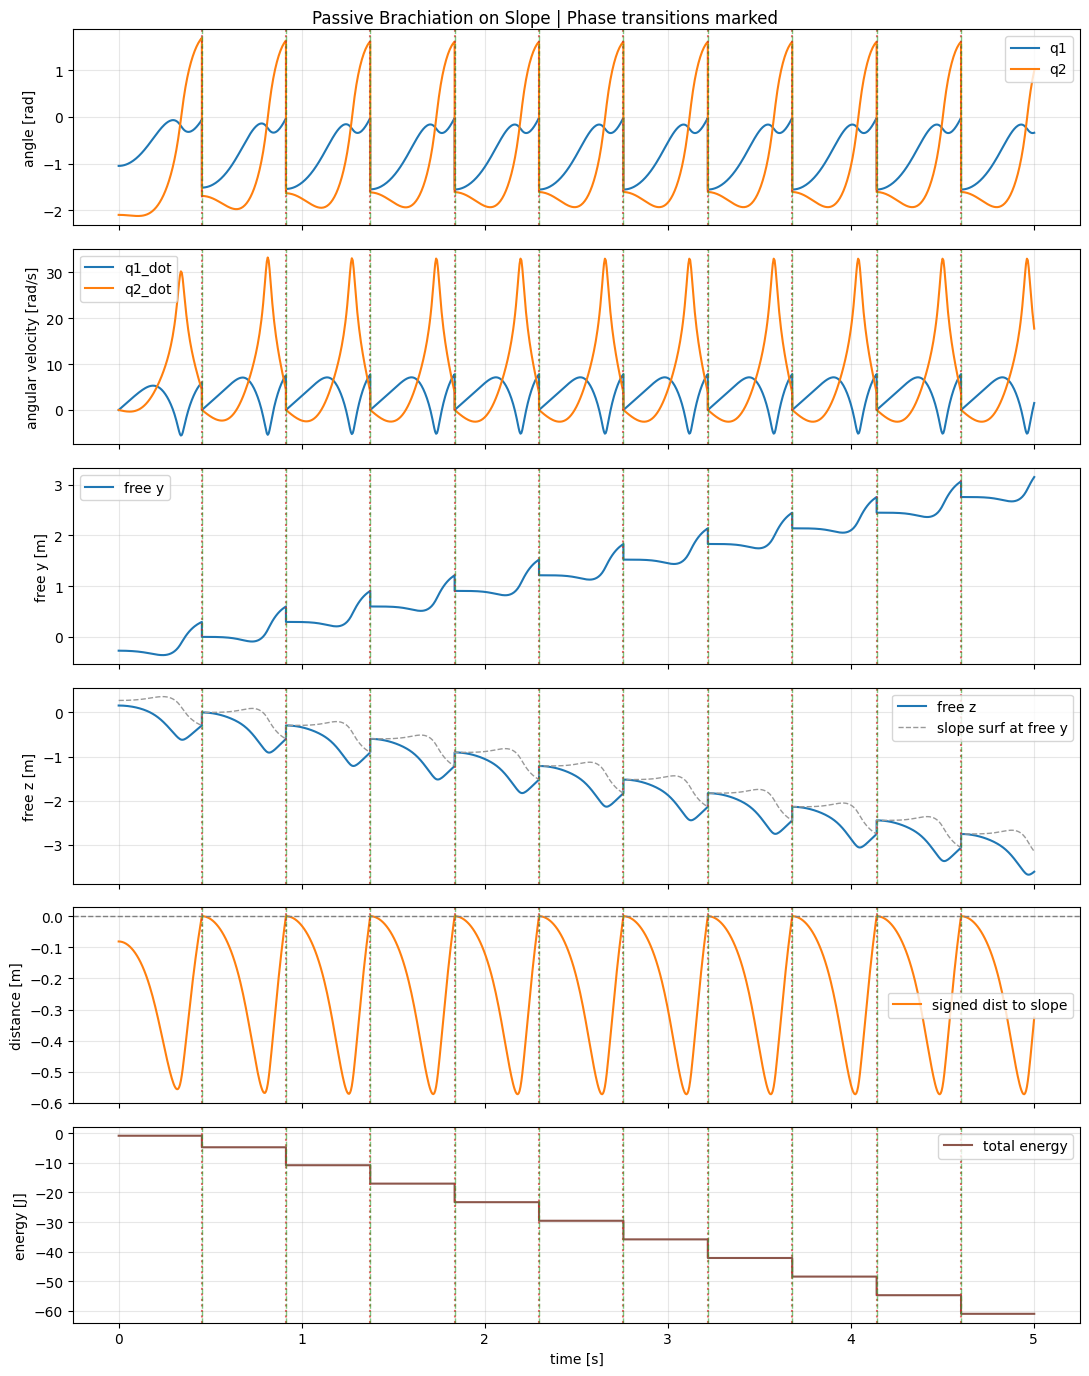

In [7]:
t = history["times"]
q = history["q"]
qd = history["qd"]
phase = history["phase"]
frees = history["frees"]
supports = history["supports"]
free_dist = history["free_dist"]
torques = history["torques"]
total_energy = history["total_energy"]

# Find impact and release times
impact_mask = phase == "impact"
release_mask = phase == "release"
dwell_mask = phase == "dwelling"

fig, axes = plt.subplots(6, 1, figsize=(11, 14), sharex=True)

# ── q ──
axes[0].plot(t, q[:, 0], label="q1")
axes[0].plot(t, q[:, 1], label="q2")
axes[0].set_ylabel("angle [rad]")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# ── qd ──
axes[1].plot(t, qd[:, 0], label="q1_dot")
axes[1].plot(t, qd[:, 1], label="q2_dot")
axes[1].set_ylabel("angular velocity [rad/s]")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── free endpoint y ──
axes[2].plot(t, frees[:, 0], label="free y")
axes[2].set_ylabel("free y [m]")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# ── free endpoint z ──
axes[3].plot(t, frees[:, 1], label="free z")
# Plot the local slope surface at the free y: z_slope = -y*tan(gamma)
axes[3].plot(t, -frees[:, 0] * np.tan(GAMMA), color="0.6", linestyle="--", linewidth=1, label="slope surf at free y")
axes[3].set_ylabel("free z [m]")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# ── signed distance to slope ──
axes[4].plot(t, free_dist, color="tab:orange", label="signed dist to slope")
axes[4].axhline(0.0, color="0.5", linestyle="--", linewidth=1)
axes[4].set_ylabel("distance [m]")
axes[4].legend()
axes[4].grid(True, alpha=0.3)

# ── total energy ──
axes[5].plot(t, total_energy, color="tab:brown", label="total energy")
axes[5].set_ylabel("energy [J]")
axes[5].set_xlabel("time [s]")
axes[5].legend()
axes[5].grid(True, alpha=0.3)

# Mark phase transitions
for ax in axes:
    for impact_time in t[impact_mask]:
        ax.axvline(impact_time, color="tab:red", linestyle=":", linewidth=1.5, alpha=0.7)
    for release_time in t[release_mask]:
        ax.axvline(release_time, color="tab:green", linestyle="--", linewidth=1.0, alpha=0.6)

fig.suptitle("Passive Brachiation on Slope | Phase transitions marked")
fig.tight_layout()
plt.show()

## 7. End‑Point Trajectory in the y‑z Plane

The slope surface is drawn as a solid ground line.

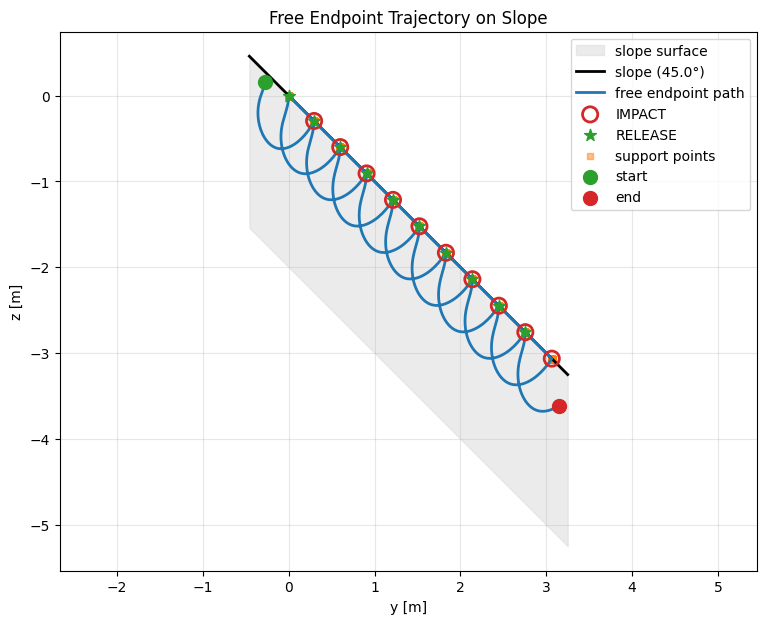

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

# Slope surface line
y_lim = np.array([frees[:, 0].min() - 0.1, frees[:, 0].max() + 0.1])
z_slope = -y_lim * np.tan(GAMMA)
ax.fill_between(y_lim, z_slope - 2.0, z_slope, color="0.85", alpha=0.5, label="slope surface")
ax.plot(y_lim, z_slope, color="black", linewidth=2, label=f"slope ({np.rad2deg(GAMMA):.1f}°)")

# Free‑end trajectory
ax.plot(frees[:, 0], frees[:, 1], color="tab:blue", linewidth=2.0, label="free endpoint path")

# Mark impact and release points
if np.any(impact_mask):
    ax.scatter(frees[impact_mask, 0], frees[impact_mask, 1],
               s=120, marker="o", facecolors="none", edgecolors="tab:red",
               linewidths=2, label="IMPACT", zorder=5)
if np.any(release_mask):
    ax.scatter(frees[release_mask, 0], frees[release_mask, 1],
               s=80, marker="*", color="tab:green", label="RELEASE", zorder=5)

# Support‑point trajectory
ax.scatter(supports[:, 0], supports[:, 1], s=15, marker="s", color="tab:orange", alpha=0.5, label="support points")

# Start / end
ax.scatter(frees[0, 0], frees[0, 1], s=100, color="tab:green", label="start", zorder=6)
ax.scatter(frees[-1, 0], frees[-1, 1], s=100, color="tab:red", label="end", zorder=6)

ax.set_xlabel("y [m]")
ax.set_ylabel("z [m]")
ax.set_title("Free Endpoint Trajectory on Slope")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

## 8. Animation

Blue chain = two‑link model.  Red square = current support point.  Grey
region = slope surface (infinite plane).  Phase label shown in the top‑left corner.

In [9]:

'''# Downsample for lightweight browser playback
stride = max(1, len(samples) // 300)
frame_indices = np.arange(0, len(samples), stride)

elbows = history["elbows"]
frees = history["frees"]
supports = history["supports"]
all_pts = np.vstack([elbows, frees, supports])

margin = 0.15
y_min, z_min = all_pts.min(axis=0) - margin
y_max, z_max = all_pts.max(axis=0) + margin

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_xlim(y_min, y_max)
ax.set_ylim(z_min, z_max)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.set_xlabel("y [m]")
ax.set_ylabel("z [m]")

# Draw slope surface (static)
y_grid = np.linspace(y_min, y_max, 200)
z_grid = -y_grid * np.tan(GAMMA)
ax.fill_between(y_grid, z_grid - 1.0, z_grid, color="0.85", alpha=0.4)
ax.plot(y_grid, z_grid, color="black", linewidth=2, label=f"slope {np.rad2deg(GAMMA):.1f}°")

# Artists
support_artist = ax.scatter([], [], s=150, marker="s", color="tab:red", label="support", zorder=5)
link_line, = ax.plot([], [], "o-", color="tab:blue", linewidth=4, markersize=10, label="two‑link model", zorder=4)
free_trace, = ax.plot([], [], color="tab:cyan", linewidth=1.5, alpha=0.7, label="free‑end trace")
phase_text = ax.text(0.02, 0.96, "", transform=ax.transAxes, va="top", fontsize=11, weight="bold")
ax.legend(loc="lower left")

def update(frame_number):
    idx = frame_indices[frame_number]
    chain_y = [supports[idx, 0], elbows[idx, 0], frees[idx, 0]]
    chain_z = [supports[idx, 1], elbows[idx, 1], frees[idx, 1]]
    link_line.set_data(chain_y, chain_z)

    support_artist.set_offsets(supports[idx].reshape(1, 2))

    end = idx + 1
    free_trace.set_data(frees[:end, 0], frees[:end, 1])

    phase_text.set_text(
        f"t = {t[idx]:.2f} s\n"
        f"phase = {phase[idx]}\n"
        f"q = [{q[idx, 0]:.3f}, {q[idx, 1]:.3f}]\n"
        f"energy = {total_energy[idx]:.3f} J"
    )
    return link_line, support_artist, free_trace, phase_text

anim = FuncAnimation(fig, update, frames=len(frame_indices), interval=30, blit=True)
plt.close(fig)
display(HTML(anim.to_jshtml()))
'''

'# Downsample for lightweight browser playback\nstride = max(1, len(samples) // 300)\nframe_indices = np.arange(0, len(samples), stride)\n\nelbows = history["elbows"]\nfrees = history["frees"]\nsupports = history["supports"]\nall_pts = np.vstack([elbows, frees, supports])\n\nmargin = 0.15\ny_min, z_min = all_pts.min(axis=0) - margin\ny_max, z_max = all_pts.max(axis=0) + margin\n\nfig, ax = plt.subplots(figsize=(9, 7))\nax.set_xlim(y_min, y_max)\nax.set_ylim(z_min, z_max)\nax.set_aspect("equal", adjustable="box")\nax.grid(True, alpha=0.25)\nax.set_xlabel("y [m]")\nax.set_ylabel("z [m]")\n\n# Draw slope surface (static)\ny_grid = np.linspace(y_min, y_max, 200)\nz_grid = -y_grid * np.tan(GAMMA)\nax.fill_between(y_grid, z_grid - 1.0, z_grid, color="0.85", alpha=0.4)\nax.plot(y_grid, z_grid, color="black", linewidth=2, label=f"slope {np.rad2deg(GAMMA):.1f}°")\n\n# Artists\nsupport_artist = ax.scatter([], [], s=150, marker="s", color="tab:red", label="support", zorder=5)\nlink_line, = ax.plo

## 9. Next Steps & Experiment Ideas

- **Poincaré map**: Section on the slope surface (free‑end signed distance = 0).
  Extract `(q1, q2)` at each IMPACT event and iterate to find fixpoints.
- **Vary slope angle**: Change `GAMMA` to see how the passive swing changes.
- **Add damping**: Set `damping1` / `damping2` to small positive values.
- **Active control**: Replace `torque_policy` with a feedback controller.

## 10. NOT SWITCH Test

After impact, the robot releases the free end while keeping the same support.
This should produce a **bouncing** motion: the free end swings back away from
the slope after each impact.

In [10]:
print("=== NOT SWITCH Test ===")
samples_not = simulate(
    model=model,
    slope=slope,
    initial_state=initial_state,
    initial_support_point=INITIAL_SUPPORT,
    duration=2.0,
    dt=0.005,
    torque_policy=torque_policy,
    endpoint_force_policy=endpoint_force_policy,
    generalized_force_policy=generalized_force_policy,
    switch_policy=lambda *_: SwitchDecision.NO_SWITCH,
)
phases_not = {s.phase.value for s in samples_not}
impact_times_not = [s.time for s in samples_not if s.phase.value == "impact"]
print(f"Phases seen: {phases_not}")
print(f"Number of impact events: {len(impact_times_not)}")
if impact_times_not:
    print(f"Impact times: {impact_times_not}")

=== NOT SWITCH Test ===
Phases seen: {'release', 'swinging', 'impact'}
Number of impact events: 2
Impact times: [0.45467478536486666, 1.59824113567198]


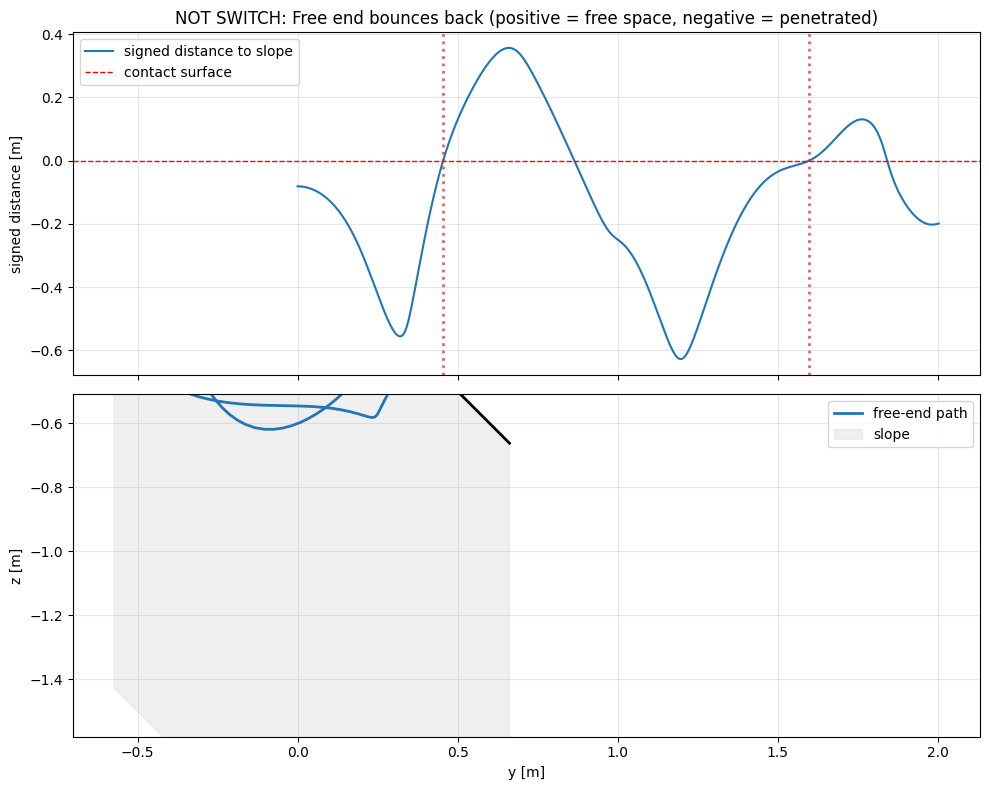

In [11]:
# Plot NOT SWITCH trajectory
t_not = np.array([s.time for s in samples_not])
frees_not = np.vstack([s.free_end for s in samples_not])
dists_not = np.array([slope.signed_distance(f) for f in frees_not])

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t_not, dists_not, label="signed distance to slope")
axes[0].axhline(0.0, color="red", linestyle="--", linewidth=1, label="contact surface")
for itime in impact_times_not:
    axes[0].axvline(itime, color="tab:red", linestyle=":", linewidth=2, alpha=0.7)
axes[0].set_ylabel("signed distance [m]")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title("NOT SWITCH: Free end bounces back (positive = free space, negative = penetrated)")

axes[1].plot(frees_not[:, 0], frees_not[:, 1], color="tab:blue", linewidth=2, label="free-end path")
y_vals = np.array([frees_not[:, 0].min() - 0.05, frees_not[:, 0].max() + 0.05])
axes[1].fill_between(y_vals, -y_vals * np.tan(GAMMA) - 2.0, -y_vals * np.tan(GAMMA),
                       color="0.85", alpha=0.4, label="slope")
axes[1].plot(y_vals, -y_vals * np.tan(GAMMA), color="black", linewidth=2)
axes[1].set_xlabel("y [m]")
axes[1].set_ylabel("z [m]")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axis("equal")

fig.tight_layout()
plt.show()

## 11. DWELL Test

After impact, the robot enters a double‑support rest phase.  The state should
freeze (all velocities zero) and the simulation should record dwelling samples
for the remaining time.

In [12]:
print("=== DWELL Test ===")
samples_dwell = simulate(
    model=model,
    slope=slope,
    initial_state=initial_state,
    initial_support_point=INITIAL_SUPPORT,
    duration=2.0,
    dt=0.005,
    torque_policy=torque_policy,
    endpoint_force_policy=endpoint_force_policy,
    generalized_force_policy=generalized_force_policy,
    switch_policy=lambda *_: SwitchDecision.DWELL,
)
phases_dwell = {s.phase.value for s in samples_dwell}
# Count dwelling samples
n_dwell = sum(1 for s in samples_dwell if s.phase.value == "dwelling")
n_swing = sum(1 for s in samples_dwell if s.phase.value == "swinging")
n_impact = sum(1 for s in samples_dwell if s.phase.value == "impact")
print(f"Phases seen: {phases_dwell}")
print(f"Swinging samples: {n_swing},  Impact samples: {n_impact},  Dwelling samples: {n_dwell}")
print(f"Final q:  {samples_dwell[-1].state.q}")
print(f"Final qd: {samples_dwell[-1].state.qd}")
print(f"Final total energy: {samples_dwell[-1].total_energy:.3f} J")

=== DWELL Test ===
Phases seen: {'swinging', 'dwelling', 'impact'}
Swinging samples: 401,  Impact samples: 1,  Dwelling samples: 1
Final q:  [-0.32838948  1.28368148]
Final qd: [-0.32591615 -6.22443692]
Final total energy: -4.706 J


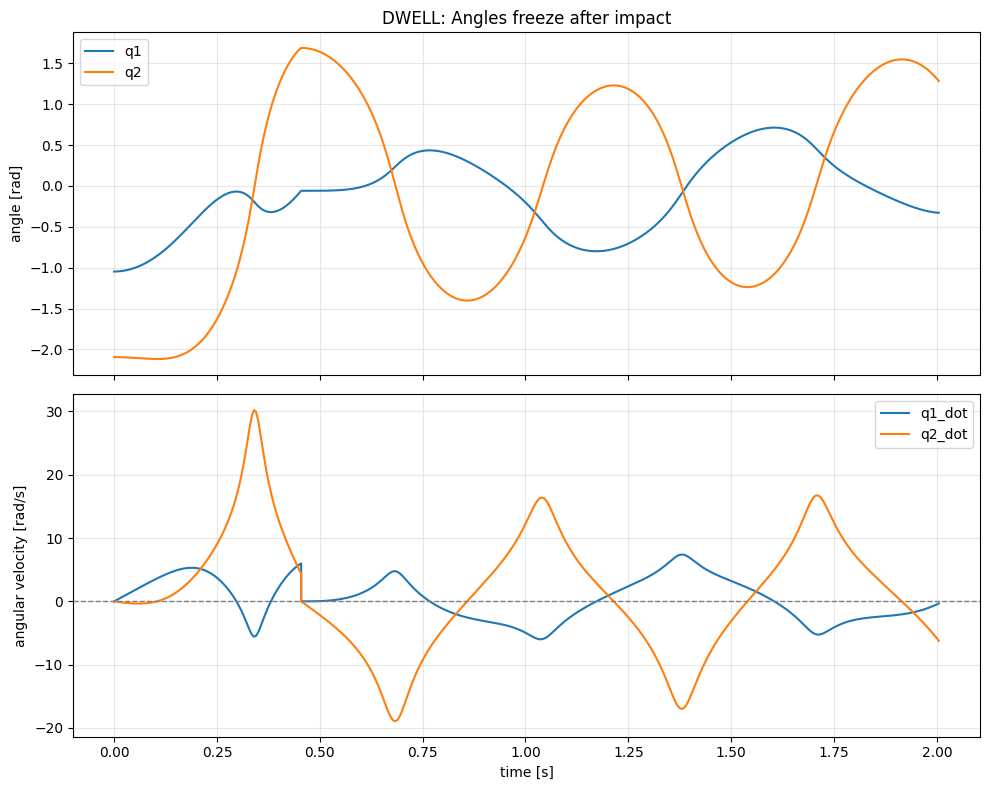

In [13]:
# Plot DWELL behavior
t_dwell = np.array([s.time for s in samples_dwell])
q_dwell = np.vstack([s.state.q for s in samples_dwell])
qd_dwell = np.vstack([s.state.qd for s in samples_dwell])

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t_dwell, q_dwell[:, 0], label="q1")
axes[0].plot(t_dwell, q_dwell[:, 1], label="q2")
axes[0].set_ylabel("angle [rad]")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title("DWELL: Angles freeze after impact")

axes[1].plot(t_dwell, qd_dwell[:, 0], label="q1_dot")
axes[1].plot(t_dwell, qd_dwell[:, 1], label="q2_dot")
axes[1].axhline(0.0, color="0.5", linestyle="--", linewidth=1)
axes[1].set_ylabel("angular velocity [rad/s]")
axes[1].set_xlabel("time [s]")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 1-D stride-distance residual scan for period-1 and period-2 gaits

This section solves fixed-point equations in the stride coordinate `d`. Period-1 roots use `F(d)=P(d)-d`; period-2 roots use `F2(d)=P(P(d))-d` and exclude period-1 duplicates. Each candidate is validated by elbow-section legality over the whole candidate period and by the eigenvalues of the matching Poincare map.


In [ ]:
from passive_brachiation import (
    CollisionMode,
    evaluate_passive_brachiation_stride,
    scan_stride_fixed_points,
)

# Current notebook parameters are reused: params, model, slope, GAMMA.
shoot_dt = 0.005
shoot_t_max = 8.0
d_bounds = (0.05, 0.95 * (params.l1 + params.l2))
d_scan_points = 30
stride_branches = ("positive", "negative")
periods_to_scan = (1, 2)
initial_direction = -1.0
impact_direction = 1.0
slope_tangent = np.array([np.cos(GAMMA), -np.sin(GAMMA)])

print("=== stride residual sign-change scan ===")
print(f"d bounds: [{d_bounds[0]:.6f}, {d_bounds[1]:.6f}] m")
print(f"scan points per branch/period: {d_scan_points}")

stride_search = scan_stride_fixed_points(
    model=model,
    slope=slope,
    initial_support_point=INITIAL_SUPPORT,
    dt=shoot_dt,
    t_max=shoot_t_max,
    d_bounds=d_bounds,
    d_scan_points=d_scan_points,
    branches=stride_branches,
    periods=periods_to_scan,
    initial_direction=initial_direction,
    impact_direction=impact_direction,
    switch_policy=switch_policy,
    collision_mode=CollisionMode.FULL_GRAB_1D,
    residual_tol=1e-7,
    root_xtol=1e-10,
    root_rtol=1e-10,
    root_maxiter=60,
    jacobian_delta=1e-5,
    validation_duration=8.0,
    validation_tail_count=8,
    legality_tolerance=1e-9,
    period_duplicate_tol=1e-6,
)

d_scan_results = stride_search.scan_results
d_trials = stride_search.trials
legal_trials = stride_search.legal_trials
selected_trial = stride_search.selected_trial
if selected_trial is None:
    raise RuntimeError("No legal period-1/period-2 stride fixed point found for the current setup.")

for branch in stride_branches:
    for period in periods_to_scan:
        result = d_scan_results[(branch, period)]
        scan = result["scan"]
        roots = result["roots"]
        print()
        print(f"branch={branch}, period={period}: brackets={len(scan.brackets)}, roots={len(roots)}")
        for bracket in scan.brackets:
            print(
                f"  [{bracket.lower:.6f}, {bracket.upper:.6f}]  "
                f"F(lo)={bracket.residual_lower:+.3e}, F(hi)={bracket.residual_upper:+.3e}"
            )
        for root in roots:
            print(
                f"  d={root.x:.9f} m, P^{period}(d)={root.p_of_x:.9f} m, "
                f"|F|={root.residual_norm:.3e}, calls={root.function_calls}"
            )

for trial in d_trials:
    print(
        f"  candidate d={trial.d:.9f} ({trial.branch}, period={trial.period}): "
        f"legal={trial.legality.legal}, max elbow signed dist={trial.legality.max_signed_distance:+.3e}, "
        f"rho={trial.spectral_radius:.6f}, stable={trial.stable}, "
        f"tail stride half-range={trial.validation_error:.3e}"
    )

d_root = selected_trial.root
d_fixed = float(selected_trial.d)
selected_branch = selected_trial.branch
selected_period = int(selected_trial.period)
q2_fixed = float(selected_trial.q0[1])
best_branch = f"stride_distance_{selected_branch}_period{selected_period}_brent"
q2_validation_release_q2 = selected_trial.validation_release_q2
d_validation_release_stride = selected_trial.validation_release_stride
d_validation_error = selected_trial.validation_error
d_validation_std = selected_trial.validation_std
d_best_residual = d_root.residual_norm
q2_best_residual = d_best_residual
q2_validation_error = d_validation_error
q2_validation_std = d_validation_std
q2_legality = selected_trial.legality
q2_jacobian = selected_trial.jacobian
q2_eigenvalues = selected_trial.eigenvalues
q2_spectral_radius = selected_trial.spectral_radius
q2_is_stable = selected_trial.stable
P_d_selected = selected_trial.P
P_d_base_selected = selected_trial.P_base

print()
print("=== Selected legal stride fixed point ===")
print(f"slope angle: {np.rad2deg(GAMMA):.1f} deg")
print(f"branch = {selected_branch}, period = {selected_period}")
print(f"d* = {d_fixed:.9f} m")
print(f"equivalent q2* = {q2_fixed:+.9f} rad")
print(f"Brent residual |P^{selected_period}(d*) - d*| = {d_best_residual:.3e} m")
print(f"tail stride half-range = {d_validation_error:.3e} m")
print(f"elbow legality: {q2_legality.legal}, max signed distance = {q2_legality.max_signed_distance:+.3e} m")
print(f"Poincare Jacobian = {q2_jacobian}")
print(f"eigenvalues = {q2_eigenvalues}")
print(f"spectral radius = {q2_spectral_radius:.6f}, stable = {q2_is_stable}")

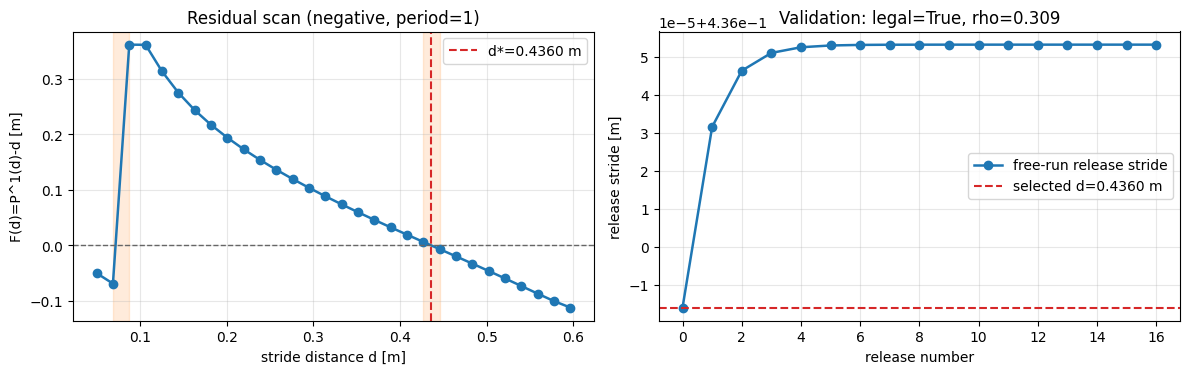

One-stride check: P(d*) = 0.435983940 m
Selected-period residual: -4.274e-15 m
Samples in fixed-stride trajectory: 1631
Equivalent q2*: -1.606860395 rad
Elbow legality max signed distance: -2.259e-01 m
Poincare eigenvalues: [0.30945536]
Stable by |lambda|max < 1: True


In [15]:
# Visualize the selected branch/period residual scan and physical validation.
selected_scan = d_scan_results[(selected_branch, selected_period)]["scan"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

finite_scan = np.isfinite(selected_scan.residuals)
axes[0].plot(selected_scan.grid[finite_scan], selected_scan.residuals[finite_scan], "o-", linewidth=1.8)
axes[0].axhline(0.0, color="0.4", linestyle="--", linewidth=1)
for bracket in selected_scan.brackets:
    axes[0].axvspan(bracket.lower, bracket.upper, color="tab:orange", alpha=0.15)
axes[0].axvline(d_fixed, color="tab:red", linestyle="--", label=f"d*={d_fixed:.4f} m")
axes[0].set_xlabel("stride distance d [m]")
axes[0].set_ylabel(f"F(d)=P^{selected_period}(d)-d [m]")
axes[0].set_title(f"Residual scan ({selected_branch}, period={selected_period})")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(d_validation_release_stride, "o-", linewidth=1.8, label="free-run release stride")
axes[1].axhline(d_fixed, color="tab:red", linestyle="--", label=f"selected d={d_fixed:.4f} m")
axes[1].set_xlabel("release number")
axes[1].set_ylabel("release stride [m]")
axes[1].set_title(f"Validation: legal={q2_legality.legal}, rho={q2_spectral_radius:.3f}")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

stride_eval = evaluate_passive_brachiation_stride(
    model=model,
    slope=slope,
    x=np.array([d_fixed]),
    dt=shoot_dt,
    t_max=shoot_t_max,
    collision_mode=CollisionMode.FULL_GRAB_1D,
    initial_direction=initial_direction,
    impact_direction=impact_direction,
    branch=selected_branch,
)
q2_stride_eval = stride_eval
print(f"One-stride check: P(d*) = {stride_eval.p_of_x[0]:.9f} m")
print(f"Selected-period residual: {P_d_selected(np.array([d_fixed]))[0] - d_fixed:+.3e} m")
print(f"Samples in fixed-stride trajectory: {len(stride_eval.samples)}")
print(f"Equivalent q2*: {q2_fixed:+.9f} rad")
print(f"Elbow legality max signed distance: {q2_legality.max_signed_distance:+.3e} m")
print(f"Poincare eigenvalues: {q2_eigenvalues}")
print(f"Stable by |lambda|max < 1: {q2_is_stable}")


## q2 fixed-point free-run visualization

Using the physically validated `q2_fixed`, this section starts with the free end upslope of the support and runs the real full-grab switching simulation.


In [16]:
from passive_brachiation import ik_from_q2_on_slope

if 'q2_fixed' not in globals():
    raise RuntimeError('Run the q2 shooting cell first so q2_fixed exists.')

fixed_q0 = ik_from_q2_on_slope(
    q2_fixed,
    slope=slope,
    parameters=params,
    direction=-1.0,
)
fixed_initial_state = BrachiationState(
    q=fixed_q0,
    qd=np.zeros(2, dtype=float),
    support_index=0,
)

fixed_duration = 8.0
fixed_samples = simulate(
    model=model,
    slope=slope,
    initial_state=fixed_initial_state,
    initial_support_point=INITIAL_SUPPORT,
    duration=fixed_duration,
    dt=shoot_dt,
    torque_policy=torque_policy,
    endpoint_force_policy=endpoint_force_policy,
    generalized_force_policy=generalized_force_policy,
    switch_policy=switch_policy,
    collision_mode=CollisionMode.FULL_GRAB_1D,
)

fixed_history = samples_to_arrays(fixed_samples, slope=slope)
fixed_t = fixed_history['times']
fixed_q = fixed_history['q']
fixed_qd = fixed_history['qd']
fixed_phase = fixed_history['phase']
fixed_elbows = fixed_history['elbows']
fixed_frees = fixed_history['frees']
fixed_supports = fixed_history['supports']
fixed_total_energy = fixed_history['total_energy']
fixed_kinetic_energy = fixed_history['kinetic_energy']
fixed_potential_energy = fixed_history['potential_energy']
fixed_free_dist = fixed_history['free_dist']
fixed_impact_mask = fixed_phase == 'impact'
fixed_release_mask = fixed_phase == 'release'

slope_tangent = np.array([np.cos(GAMMA), -np.sin(GAMMA)])
fixed_support_s = fixed_supports @ slope_tangent
fixed_release_stride = np.diff(np.r_[0.0, fixed_support_s[fixed_release_mask]])
fixed_release_q2 = fixed_q[fixed_release_mask, 1]

print('=== q2 fixed-point free-run simulation ===')
print(f'q2* = {q2_fixed:+.9f} rad')
print(f'equivalent endpoint stride d(q2*) = {d_fixed:.9f} m')
print(f'initial q = {fixed_q0}')
print(f'initial free endpoint = {fixed_frees[0]}')
print(f'initial signed distance = {fixed_free_dist[0]:+.3e} m')
print(f'samples = {len(fixed_samples)}')
print(f'impacts = {fixed_impact_mask.sum()}, releases = {fixed_release_mask.sum()}')
print('release q2:', np.round(fixed_release_q2[:10], 6))
print('release stride distances:', np.round(fixed_release_stride[:10], 6))


=== q2 fixed-point free-run simulation ===
q2* = -1.606860395 rad
equivalent endpoint stride d(q2*) = 0.435983940 m
initial q = [-1.55276429 -1.60686039]
initial free endpoint = [-0.3082872  0.3082872]
initial signed distance = +2.776e-17 m
samples = 1631
impacts = 17, releases = 17
release q2: [-1.606563 -1.606352 -1.606286 -1.606265 -1.606259 -1.606257 -1.606256
 -1.606256 -1.606256 -1.606256]
release stride distances: [0.435984 0.436031 0.436046 0.436051 0.436052 0.436053 0.436053 0.436053
 0.436053 0.436053]


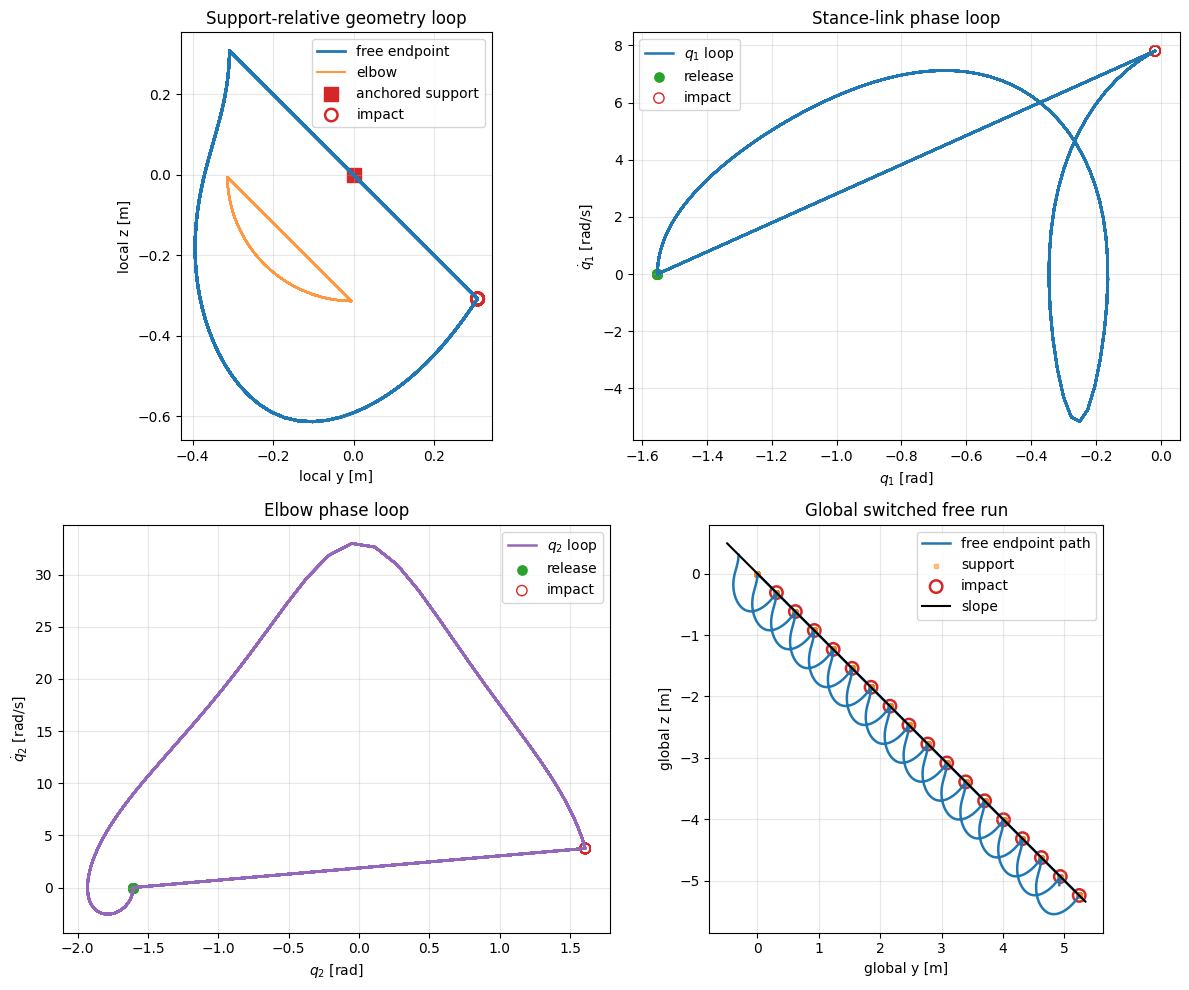

In [17]:
# Anchored limit-cycle plots.
local_elbows = fixed_elbows - fixed_supports
local_frees = fixed_frees - fixed_supports

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(local_frees[:, 0], local_frees[:, 1], color='tab:blue', linewidth=2, label='free endpoint')
axes[0, 0].plot(local_elbows[:, 0], local_elbows[:, 1], color='tab:orange', linewidth=1.5, alpha=0.8, label='elbow')
axes[0, 0].scatter([0], [0], s=90, marker='s', color='tab:red', label='anchored support')
axes[0, 0].scatter(local_frees[fixed_impact_mask, 0], local_frees[fixed_impact_mask, 1], s=80, facecolors='none', edgecolors='tab:red', linewidths=1.8, label='impact')
axes[0, 0].set_aspect('equal', adjustable='box')
axes[0, 0].set_xlabel('local y [m]')
axes[0, 0].set_ylabel('local z [m]')
axes[0, 0].set_title('Support-relative geometry loop')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='best')

axes[0, 1].plot(fixed_q[:, 0], fixed_qd[:, 0], linewidth=1.8, label=r'$q_1$ loop')
axes[0, 1].scatter(fixed_q[fixed_release_mask, 0], fixed_qd[fixed_release_mask, 0], s=45, color='tab:green', label='release')
axes[0, 1].scatter(fixed_q[fixed_impact_mask, 0], fixed_qd[fixed_impact_mask, 0], s=55, facecolors='none', edgecolors='tab:red', label='impact')
axes[0, 1].set_xlabel(r'$q_1$ [rad]')
axes[0, 1].set_ylabel(r'$\dot q_1$ [rad/s]')
axes[0, 1].set_title(r'Stance-link phase loop')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(loc='best')

axes[1, 0].plot(fixed_q[:, 1], fixed_qd[:, 1], linewidth=1.8, color='tab:purple', label=r'$q_2$ loop')
axes[1, 0].scatter(fixed_q[fixed_release_mask, 1], fixed_qd[fixed_release_mask, 1], s=45, color='tab:green', label='release')
axes[1, 0].scatter(fixed_q[fixed_impact_mask, 1], fixed_qd[fixed_impact_mask, 1], s=55, facecolors='none', edgecolors='tab:red', label='impact')
axes[1, 0].set_xlabel(r'$q_2$ [rad]')
axes[1, 0].set_ylabel(r'$\dot q_2$ [rad/s]')
axes[1, 0].set_title(r'Elbow phase loop')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(loc='best')

axes[1, 1].plot(fixed_frees[:, 0], fixed_frees[:, 1], color='tab:blue', linewidth=1.8, label='free endpoint path')
axes[1, 1].scatter(fixed_supports[:, 0], fixed_supports[:, 1], s=12, marker='s', color='tab:orange', alpha=0.45, label='support')
axes[1, 1].scatter(fixed_frees[fixed_impact_mask, 0], fixed_frees[fixed_impact_mask, 1], s=80, facecolors='none', edgecolors='tab:red', linewidths=1.8, label='impact')
y_lim = np.array([fixed_frees[:, 0].min() - 0.1, fixed_frees[:, 0].max() + 0.1])
axes[1, 1].plot(y_lim, -y_lim * np.tan(GAMMA), color='black', linewidth=1.5, label='slope')
axes[1, 1].set_aspect('equal', adjustable='box')
axes[1, 1].set_xlabel('global y [m]')
axes[1, 1].set_ylabel('global z [m]')
axes[1, 1].set_title('Global switched free run')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='best')

plt.tight_layout()
plt.show()


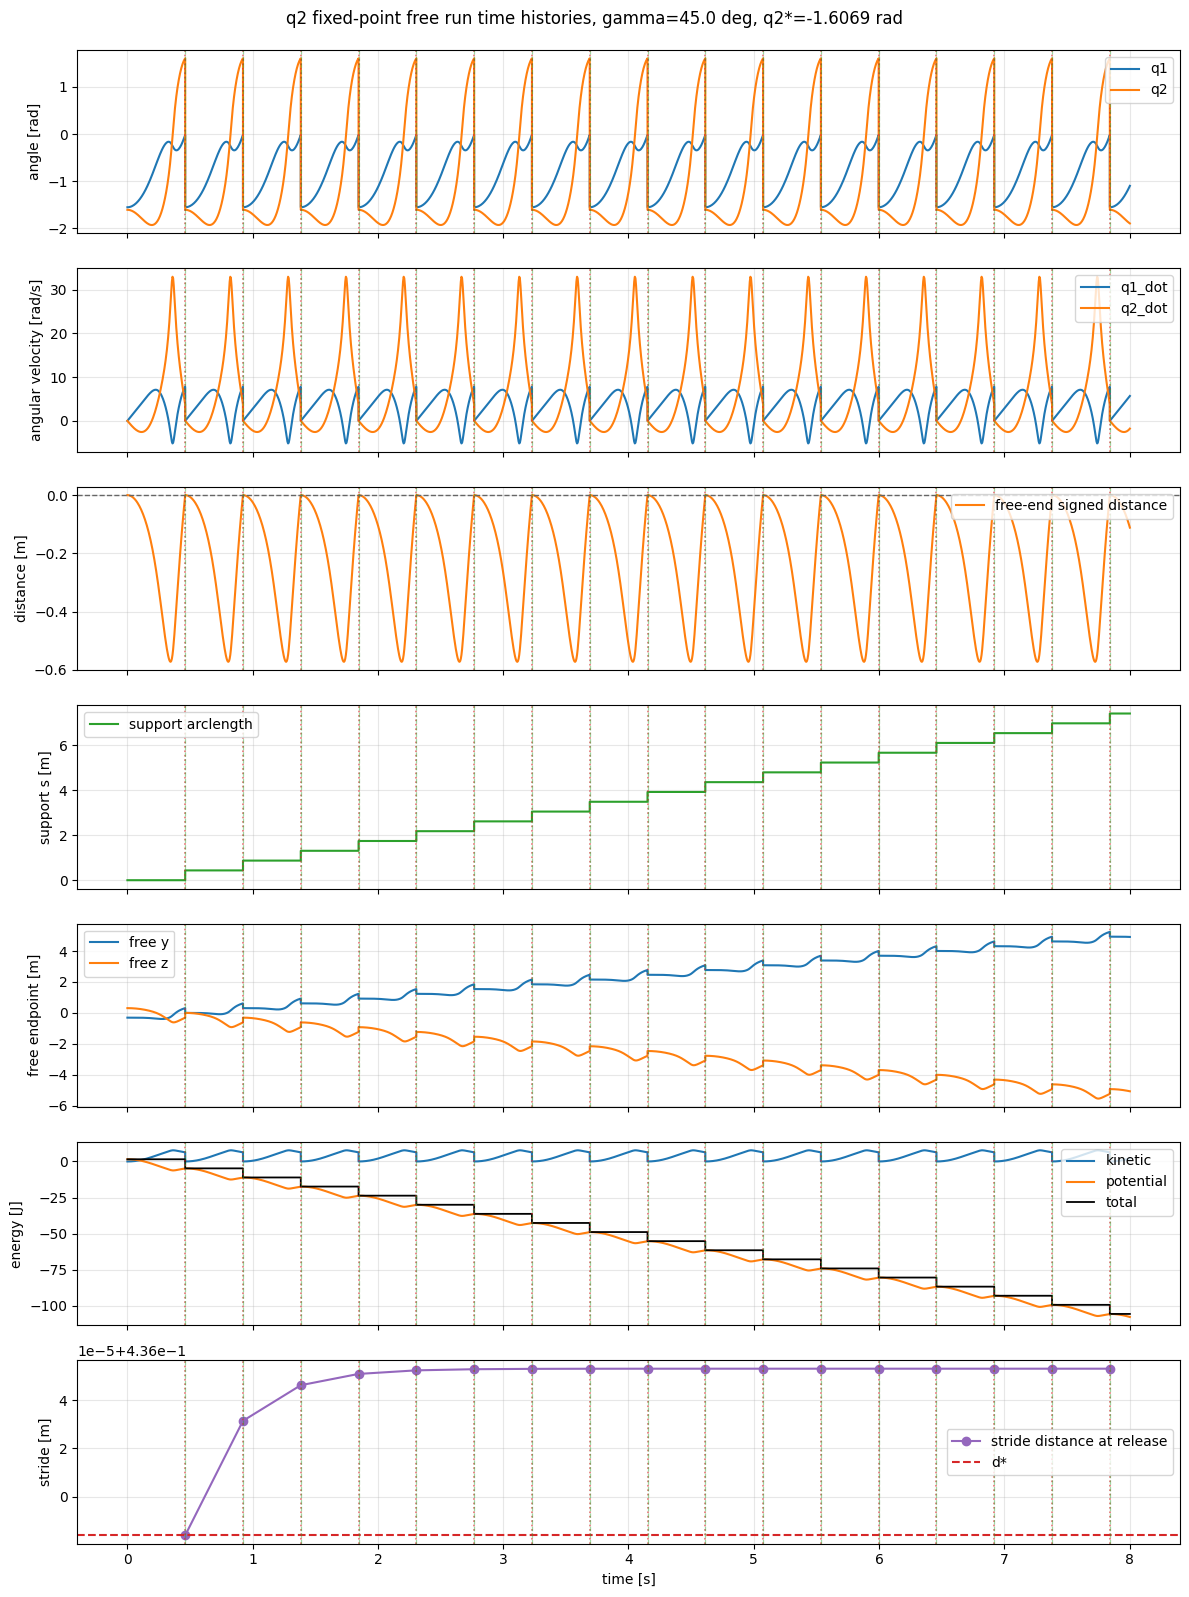

In [18]:
# Time histories for the anchored fixed gait.
fig, axes = plt.subplots(7, 1, figsize=(12, 16), sharex=True)

axes[0].plot(fixed_t, fixed_q[:, 0], label='q1')
axes[0].plot(fixed_t, fixed_q[:, 1], label='q2')
axes[0].set_ylabel('angle [rad]')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(fixed_t, fixed_qd[:, 0], label='q1_dot')
axes[1].plot(fixed_t, fixed_qd[:, 1], label='q2_dot')
axes[1].set_ylabel('angular velocity [rad/s]')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

axes[2].plot(fixed_t, fixed_free_dist, color='tab:orange', label='free-end signed distance')
axes[2].axhline(0.0, color='0.4', linestyle='--', linewidth=1)
axes[2].set_ylabel('distance [m]')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

axes[3].plot(fixed_t, fixed_support_s, color='tab:green', label='support arclength')
axes[3].set_ylabel('support s [m]')
axes[3].legend(loc='upper left')
axes[3].grid(True, alpha=0.3)

axes[4].plot(fixed_t, fixed_frees[:, 0], label='free y')
axes[4].plot(fixed_t, fixed_frees[:, 1], label='free z')
axes[4].set_ylabel('free endpoint [m]')
axes[4].legend(loc='upper left')
axes[4].grid(True, alpha=0.3)

axes[5].plot(fixed_t, fixed_kinetic_energy, label='kinetic')
axes[5].plot(fixed_t, fixed_potential_energy, label='potential')
axes[5].plot(fixed_t, fixed_total_energy, label='total', color='black', linewidth=1.3)
axes[5].set_ylabel('energy [J]')
axes[5].legend(loc='upper right')
axes[5].grid(True, alpha=0.3)

release_times = fixed_t[fixed_release_mask]
release_strides = np.diff(np.r_[0.0, fixed_support_s[fixed_release_mask]])
axes[6].plot(release_times, release_strides, 'o-', color='tab:purple', label='stride distance at release')
axes[6].axhline(d_fixed, color='tab:red', linestyle='--', label='d*')
axes[6].set_ylabel('stride [m]')
axes[6].set_xlabel('time [s]')
axes[6].legend(loc='best')
axes[6].grid(True, alpha=0.3)

for ax in axes:
    for impact_time in fixed_t[fixed_impact_mask]:
        ax.axvline(impact_time, color='tab:red', linestyle=':', linewidth=1.2, alpha=0.65)
    for release_time in fixed_t[fixed_release_mask]:
        ax.axvline(release_time, color='tab:green', linestyle='--', linewidth=0.9, alpha=0.45)

fig.suptitle(f'q2 fixed-point free run time histories, gamma={np.rad2deg(GAMMA):.1f} deg, q2*={q2_fixed:.4f} rad', y=0.995)
plt.tight_layout()
plt.show()


In [19]:
'''
# Animation of the corrected switched free run.
fixed_stride = max(1, len(fixed_t) // 360)
fixed_frame_indices = np.arange(0, len(fixed_t), fixed_stride)

fixed_all_pts = np.vstack([fixed_elbows, fixed_frees, fixed_supports])
margin = 0.18
y_min, z_min = fixed_all_pts.min(axis=0) - margin
y_max, z_max = fixed_all_pts.max(axis=0) + margin

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(y_min, y_max)
ax.set_ylim(z_min, z_max)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.25)
ax.set_xlabel('y [m]')
ax.set_ylabel('z [m]')

y_grid = np.linspace(y_min, y_max, 250)
z_grid = -y_grid * np.tan(GAMMA)
ax.fill_between(y_grid, z_grid - 1.0, z_grid, color='0.88', alpha=0.45)
ax.plot(y_grid, z_grid, color='black', linewidth=1.8, label=f'slope {np.rad2deg(GAMMA):.1f} deg')

fixed_support_artist = ax.scatter([], [], s=130, marker='s', color='tab:red', label='support', zorder=5)
fixed_link_line, = ax.plot([], [], 'o-', color='tab:blue', linewidth=4, markersize=8, label='two-link chain', zorder=4)
fixed_free_trace, = ax.plot([], [], color='tab:cyan', linewidth=1.5, alpha=0.7, label='free-end trace')
fixed_phase_text = ax.text(0.02, 0.96, '', transform=ax.transAxes, va='top', fontsize=10, weight='bold')
ax.legend(loc='lower left')

def update_fixed(frame_number):
    idx = fixed_frame_indices[frame_number]
    chain_y = [fixed_supports[idx, 0], fixed_elbows[idx, 0], fixed_frees[idx, 0]]
    chain_z = [fixed_supports[idx, 1], fixed_elbows[idx, 1], fixed_frees[idx, 1]]
    fixed_link_line.set_data(chain_y, chain_z)
    fixed_support_artist.set_offsets(fixed_supports[idx].reshape(1, 2))
    fixed_free_trace.set_data(fixed_frees[:idx + 1, 0], fixed_frees[:idx + 1, 1])
    fixed_phase_text.set_text(
        f't = {fixed_t[idx]:.2f} s\n'
        f'phase = {fixed_phase[idx]}\n'
        f'q = [{fixed_q[idx, 0]:.3f}, {fixed_q[idx, 1]:.3f}]\n'
        f'q2* = {q2_fixed:.4f} rad'
    )
    return fixed_link_line, fixed_support_artist, fixed_free_trace, fixed_phase_text

fixed_anim = FuncAnimation(fig, update_fixed, frames=len(fixed_frame_indices), interval=30, blit=True)
plt.close(fig)
display(HTML(fixed_anim.to_jshtml()))
'''

"\n# Animation of the corrected switched free run.\nfixed_stride = max(1, len(fixed_t) // 360)\nfixed_frame_indices = np.arange(0, len(fixed_t), fixed_stride)\n\nfixed_all_pts = np.vstack([fixed_elbows, fixed_frees, fixed_supports])\nmargin = 0.18\ny_min, z_min = fixed_all_pts.min(axis=0) - margin\ny_max, z_max = fixed_all_pts.max(axis=0) + margin\n\nfig, ax = plt.subplots(figsize=(10, 6))\nax.set_xlim(y_min, y_max)\nax.set_ylim(z_min, z_max)\nax.set_aspect('equal', adjustable='box')\nax.grid(True, alpha=0.25)\nax.set_xlabel('y [m]')\nax.set_ylabel('z [m]')\n\ny_grid = np.linspace(y_min, y_max, 250)\nz_grid = -y_grid * np.tan(GAMMA)\nax.fill_between(y_grid, z_grid - 1.0, z_grid, color='0.88', alpha=0.45)\nax.plot(y_grid, z_grid, color='black', linewidth=1.8, label=f'slope {np.rad2deg(GAMMA):.1f} deg')\n\nfixed_support_artist = ax.scatter([], [], s=130, marker='s', color='tab:red', label='support', zorder=5)\nfixed_link_line, = ax.plot([], [], 'o-', color='tab:blue', linewidth=4, marker

## Symmetric COM-offset continuation at the current slope

Starting from the current steady gait at centered COM (`offset = 0`), this section traces the same Poincare branch while moving both link COMs symmetrically. Positive offset moves both COMs toward the elbow joint: `lc1/L1 = 0.5 + offset`, `lc2/L2 = 0.5 - offset`. Negative offset moves both COMs toward the contact endpoints: support end for link 1 and free/grabbing end for link 2. Link inertias are kept at the current values so this isolates COM-position effects without changing the inertia model family.


In [ ]:
from passive_brachiation import CollisionMode, run_symmetric_com_continuation

if 'd_fixed' not in globals() or 'selected_branch' not in globals() or 'selected_period' not in globals():
    raise RuntimeError('Run the steady-gait search cell first so d_fixed, selected_branch, and selected_period exist.')

COM_CENTER_FRACTION = 0.5
COM_OFFSET_LOW = -0.3   # lc1/L1=0.2, lc2/L2=0.8: both COMs toward contact endpoints
COM_OFFSET_HIGH = 0.3   # lc1/L1=0.8, lc2/L2=0.2: both COMs toward the elbow
N_COM_STEPS_PER_SIDE = 31
continuation_tol = 1e-6
continuation_max_iter = 10

com_continuation = run_symmetric_com_continuation(
    base_params=params,
    slope=slope,
    d_fixed=d_fixed,
    branch=selected_branch,
    period=selected_period,
    offset_low=COM_OFFSET_LOW,
    offset_high=COM_OFFSET_HIGH,
    n_steps_per_side=N_COM_STEPS_PER_SIDE,
    dt=shoot_dt,
    t_max=shoot_t_max,
    initial_support_point=INITIAL_SUPPORT,
    initial_direction=initial_direction,
    impact_direction=impact_direction,
    switch_policy=switch_policy,
    collision_mode=CollisionMode.FULL_GRAB_1D,
    continuation_tol=continuation_tol,
    continuation_max_iter=continuation_max_iter,
    continuation_delta=1e-5,
    continuation_damping=0.8,
    center_fraction=COM_CENTER_FRACTION,
)

def com_row_to_dict(row):
    return {
        'direction': row.direction,
        'com_offset': row.com_offset,
        'lc1_fraction': row.lc1_fraction,
        'lc2_fraction': row.lc2_fraction,
        'd_primary': row.d_primary,
        'd_next': row.d_next,
        'stride_plot': row.stride_plot,
        'period': row.period,
        'converged': row.converged,
        'residual_norm': row.residual_norm,
        'spectral_radius': row.spectral_radius,
        'eigen_real': row.eigen_real,
        'stable': row.stable,
        'legal': row.legal,
        'max_elbow_distance': row.max_elbow_distance,
        'min_elbow_distance': row.min_elbow_distance,
        'release_stride': row.release_stride,
        'failure_reason': row.failure_reason,
    }

com_result_contact = com_continuation.contact_result
com_result_elbow = com_continuation.elbow_result
com_rows_contact = [com_row_to_dict(row) for row in com_continuation.contact_rows]
com_rows_elbow = [com_row_to_dict(row) for row in com_continuation.elbow_rows]
com_rows = [com_row_to_dict(row) for row in com_continuation.rows]

print('=== symmetric COM-offset continuation summary ===')
print(f'slope angle = {np.rad2deg(GAMMA):.1f} deg')
print(f'branch = {selected_branch}, period = {selected_period}')
print(f'seed: offset=0.000, lc1/L1=0.500, lc2/L2=0.500, d*={d_fixed:.9f} m')
print(f'toward contact endpoints: points={len(com_result_contact.points)}, stopped={com_result_contact.stopped_early}, reason={com_result_contact.stop_reason}')
print(f'toward elbow: points={len(com_result_elbow.points)}, stopped={com_result_elbow.stopped_early}, reason={com_result_elbow.stop_reason}')

for row in com_rows:
    status = 'OK' if row['converged'] and row['legal'] else 'BAD'
    print(
        f"{status} offset={row['com_offset']:+.3f} "
        f"lc1/L1={row['lc1_fraction']:.3f} lc2/L2={row['lc2_fraction']:.3f} "
        f"stride={row['stride_plot']:.6f} rho={row['spectral_radius']:.4f} "
        f"eig={row['eigen_real']:+.4f} legal={row['legal']}"
    )

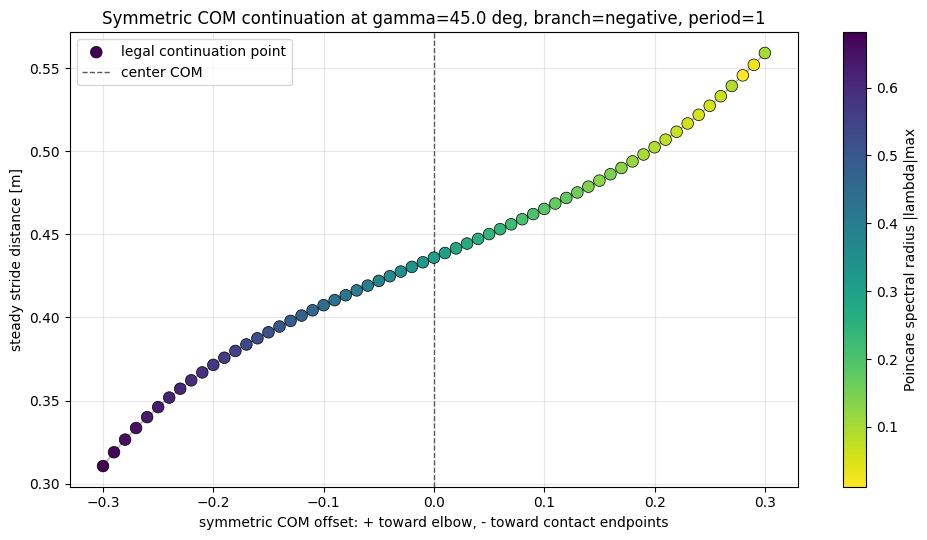

In [21]:
# Plot symmetric COM offset vs stride, colored by stability spectral radius.
plot_rows = [row for row in com_rows if row['converged'] and np.isfinite(row['stride_plot'])]
if not plot_rows:
    raise RuntimeError('No converged COM continuation points to plot.')

x = np.array([row['com_offset'] for row in plot_rows])
y = np.array([row['stride_plot'] for row in plot_rows])
rho = np.array([row['spectral_radius'] for row in plot_rows])
legal = np.array([row['legal'] for row in plot_rows], dtype=bool)
stable = np.array([row['stable'] for row in plot_rows], dtype=bool)
eig_real = np.array([row['eigen_real'] for row in plot_rows])

fig, ax = plt.subplots(figsize=(10, 5.5))
order = np.argsort(x)
ax.plot(x[order], y[order], color='0.75', linewidth=1.4, zorder=1)

scatter = ax.scatter(
    x[legal],
    y[legal],
    c=rho[legal],
    cmap='viridis_r',
    s=70,
    edgecolors='black',
    linewidths=0.5,
    zorder=3,
    label='legal continuation point',
)
if np.any(~legal):
    ax.scatter(
        x[~legal],
        y[~legal],
        marker='x',
        s=90,
        color='tab:red',
        linewidths=2,
        zorder=4,
        label='illegal geometry',
    )

unstable_idx = np.where(legal & ~stable)[0]
if len(unstable_idx):
    ax.scatter(
        x[unstable_idx],
        y[unstable_idx],
        facecolors='none',
        edgecolors='tab:red',
        s=140,
        linewidths=1.8,
        zorder=5,
        label='unstable |lambda| >= 1',
    )

# Mark likely period-doubling for a period-1 branch: real eigenvalue crosses -1.
if selected_period == 1:
    pd_candidates = np.where(legal & (eig_real <= -1.0))[0]
    if len(pd_candidates):
        idx = pd_candidates[np.argmin(np.abs(x[pd_candidates]))]
        ax.axvline(x[idx], color='tab:purple', linestyle='--', linewidth=1.3)
        ax.annotate(
            'period-doubling candidate',
            xy=(x[idx], y[idx]),
            xytext=(8, 18),
            textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='tab:purple'),
            color='tab:purple',
        )

# Mark branch-loss endpoints if continuation stopped before reaching target.
for result, rows, target_label in [
    (com_result_contact, com_rows_contact, 'branch lost toward contact endpoints'),
    (com_result_elbow, com_rows_elbow, 'branch lost toward elbow'),
]:
    if result.stopped_early and rows:
        last = rows[-1]
        ax.axvline(last['com_offset'], color='tab:red', linestyle=':', linewidth=1.3)
        if np.isfinite(last['stride_plot']):
            ax.annotate(
                target_label,
                xy=(last['com_offset'], last['stride_plot']),
                xytext=(8, -24),
                textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='tab:red'),
                color='tab:red',
            )

ax.axvline(0.0, color='0.35', linestyle='--', linewidth=1.0, label='center COM')
ax.set_xlabel('symmetric COM offset: + toward elbow, - toward contact endpoints')
ax.set_ylabel('steady stride distance [m]' if selected_period == 1 else 'mean period-2 stride distance [m]')
ax.set_title(f'Symmetric COM continuation at gamma={np.rad2deg(GAMMA):.1f} deg, branch={selected_branch}, period={selected_period}')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Poincare spectral radius |lambda|max')
plt.tight_layout()
plt.show()
